In [1]:
"""
Name: Module 2 Pearson and Distance Correlation.py
Course: Data Preparation and Analysis
Created Date: November 1, 2023
Author: Ming-Long Lam, Ph.D.
Organization: Illinois Institute of Technology
"""

'\nName: Module 2 Pearson and Distance Correlation.py\nCourse: Data Preparation and Analysis\nCreated Date: November 1, 2023\nAuthor: Ming-Long Lam, Ph.D.\nOrganization: Illinois Institute of Technology\n'

In [2]:
import matplotlib.pyplot as plt
import numpy
import pandas
import random
import sys

In [3]:
from scipy import constants
from scipy.stats import pearsonr

In [4]:
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr

In [5]:
# Set some options for printing all the columns
numpy.set_printoptions(precision = 10, threshold = sys.maxsize)
numpy.set_printoptions(linewidth = numpy.inf)

In [6]:
pandas.set_option('display.max_columns', None)
pandas.set_option('display.expand_frame_repr', False)
pandas.set_option('max_colwidth', None)

In [7]:
pandas.options.display.float_format = '{:,.10f}'.format

In [8]:
def show_xy (x, y):
   '''This function will plot y versus x, and compute the Pearson and Distance correlations.

   Parameter
   ---------
   x : a Pandas Series of x-variable
   y : a Pandas Series of y-variable

   Return
   ------
   pearson_corr : a list of two values, 0 index for Pearson correlation and 1 index for the p-value
                  of testing the population Pearson correlation is zero
   distance_corr : a list of one value, 0 index for distance correlation
   '''

   # Scatterplot of y versus x
   plt.figure(figsize = (8, 6), dpi = 200)
   plt.scatter(x, y, marker = 'o', s = 150, c = 'royalblue')
   plt.xlabel('x')
   plt.ylabel('y')
   plt.grid(axis = 'both')
   plt.show()

   # Calculate the Pearson correlation and the associated p-value
   pearson_corr = pearsonr (x, y)

   # Use the dcor() function in the R package energy to calculate the distance correlation
   distance_corr = [numpy.nan]
   with (robjects.default_converter + pandas2ri.converter).context():
      r_x = robjects.conversion.get_conversion().py2rpy(x)
      r_y = robjects.conversion.get_conversion().py2rpy(y)
      distance_corr = energy.dcor(r_x, r_y)

   return(pearson_corr, distance_corr)

In [9]:
# Import the R package energy
energy = importr("energy")

PackageNotInstalledError: The R package "energy" is not installed.

In [ ]:
# Four Points on a Straight Line
x = pandas.Series([9.0, 7.0, 4.0, 0.0], name = 'x')
y = pandas.Series([2.1, 5.9, 12.3, 19.8], name = 'y')

In [ ]:
pearson_corr, distance_corr = show_xy(x, y)
print('=== Four Points on a Straight Line === ')
print('Pearson Correlation = {:,.8f}'.format(pearson_corr[0]))
print('  Test Significance = {:,.8f}'.format(pearson_corr[1]))
print('Distance Correlation = {:,.8f}'.format(distance_corr[0]))

In [ ]:
# Thirteen Points on a Parabola Curve
theta = numpy.arange(0.0, 13.0, 1.0) * constants.pi / 12.0
x = pandas.Series(2.0 * numpy.cos(theta), name = 'x')
y = pandas.Series(2.0 * numpy.sin(theta), name = 'y')

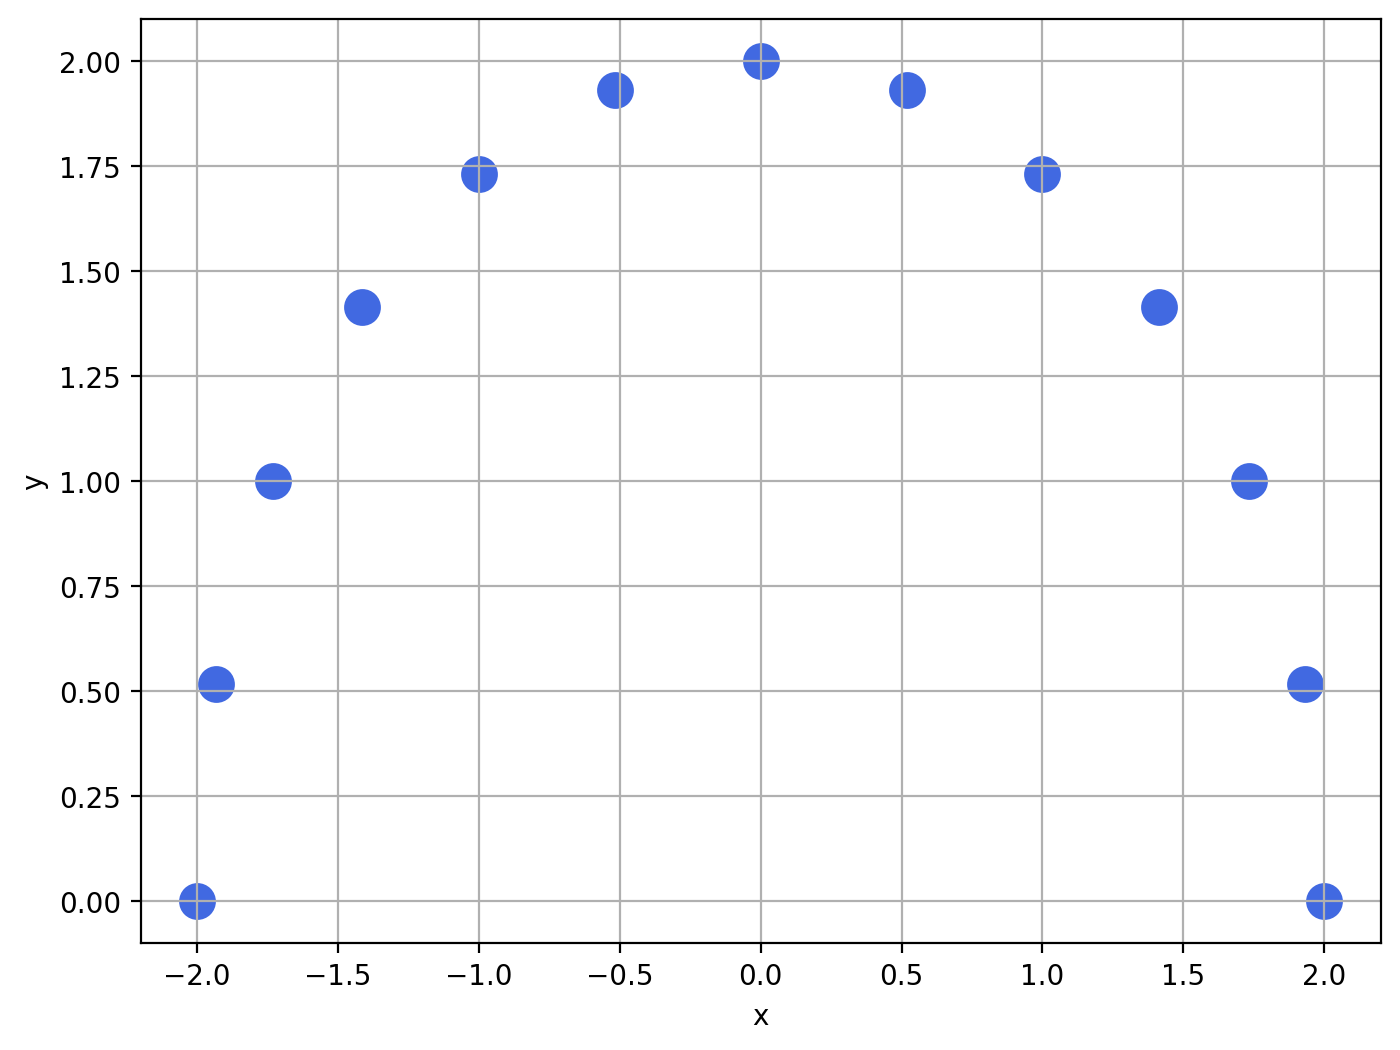

NameError: name 'energy' is not defined

In [ ]:
pearson_corr, distance_corr = show_xy(x, y)
print('=== Thirteen Points on a Parabola Curve === ')
print('Pearson Correlation = {:,.8f}'.format(pearson_corr[0]))
print('  Test Significance = {:,.8f}'.format(pearson_corr[1]))
print('Distance Correlation = {:,.8f}'.format(distance_corr[0]))

In [ ]:
# Twenty-Five Points on a Lattice Grid
x = pandas.Series([-2.0, -1.0, 0.0, 1.0, 2.0] * 5, name = 'x')
y = pandas.Series([-2.0]*5 + [-1.0]*5 + [0.0]*5 + [1.0]*5 + [2.0]*5, name = 'y')

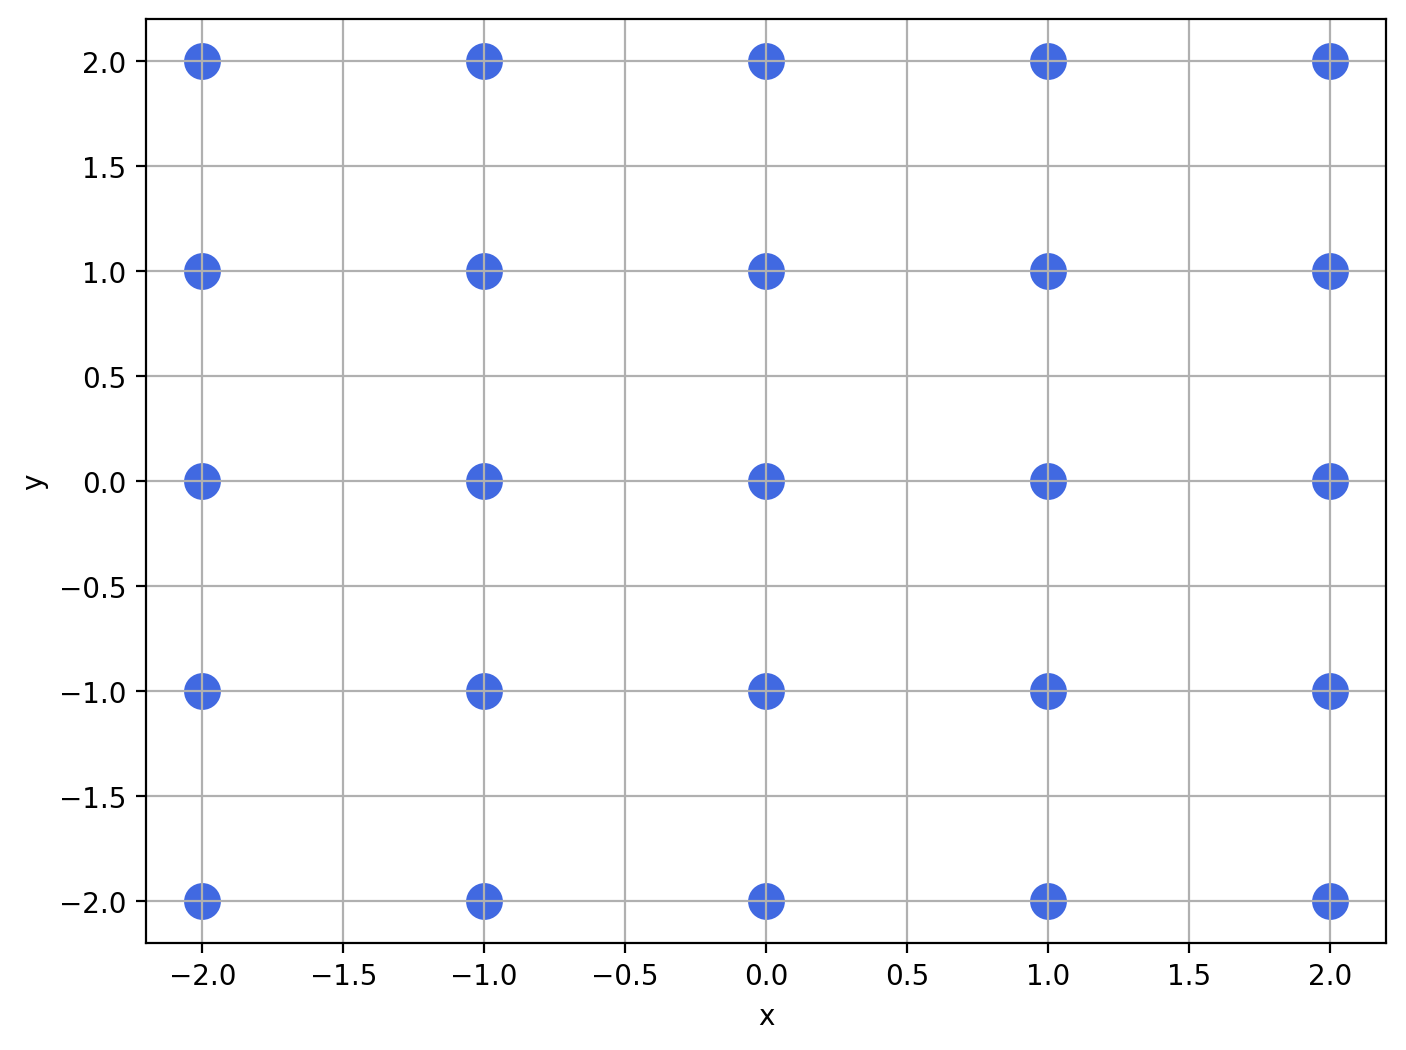

NameError: name 'energy' is not defined

In [ ]:
pearson_corr, distance_corr = show_xy(x, y)
print('=== Twenty-Five Points on a Lattice Grid === ')
print('Pearson Correlation = {:,.8f}'.format(pearson_corr[0]))
print('  Test Significance = {:,.8f}'.format(pearson_corr[1]))
print('Distance Correlation = {:,.8f}'.format(distance_corr[0]))

In [ ]:
# Five Hundred Random Points
numpy.random.seed(seed = 2023571)
x = pandas.Series(numpy.random.uniform(low = -2.0, high = 2.0, size = 500), name = 'x')
y = pandas.Series(numpy.random.uniform(low = -2.0, high = 2.0, size = 500), name = 'y')

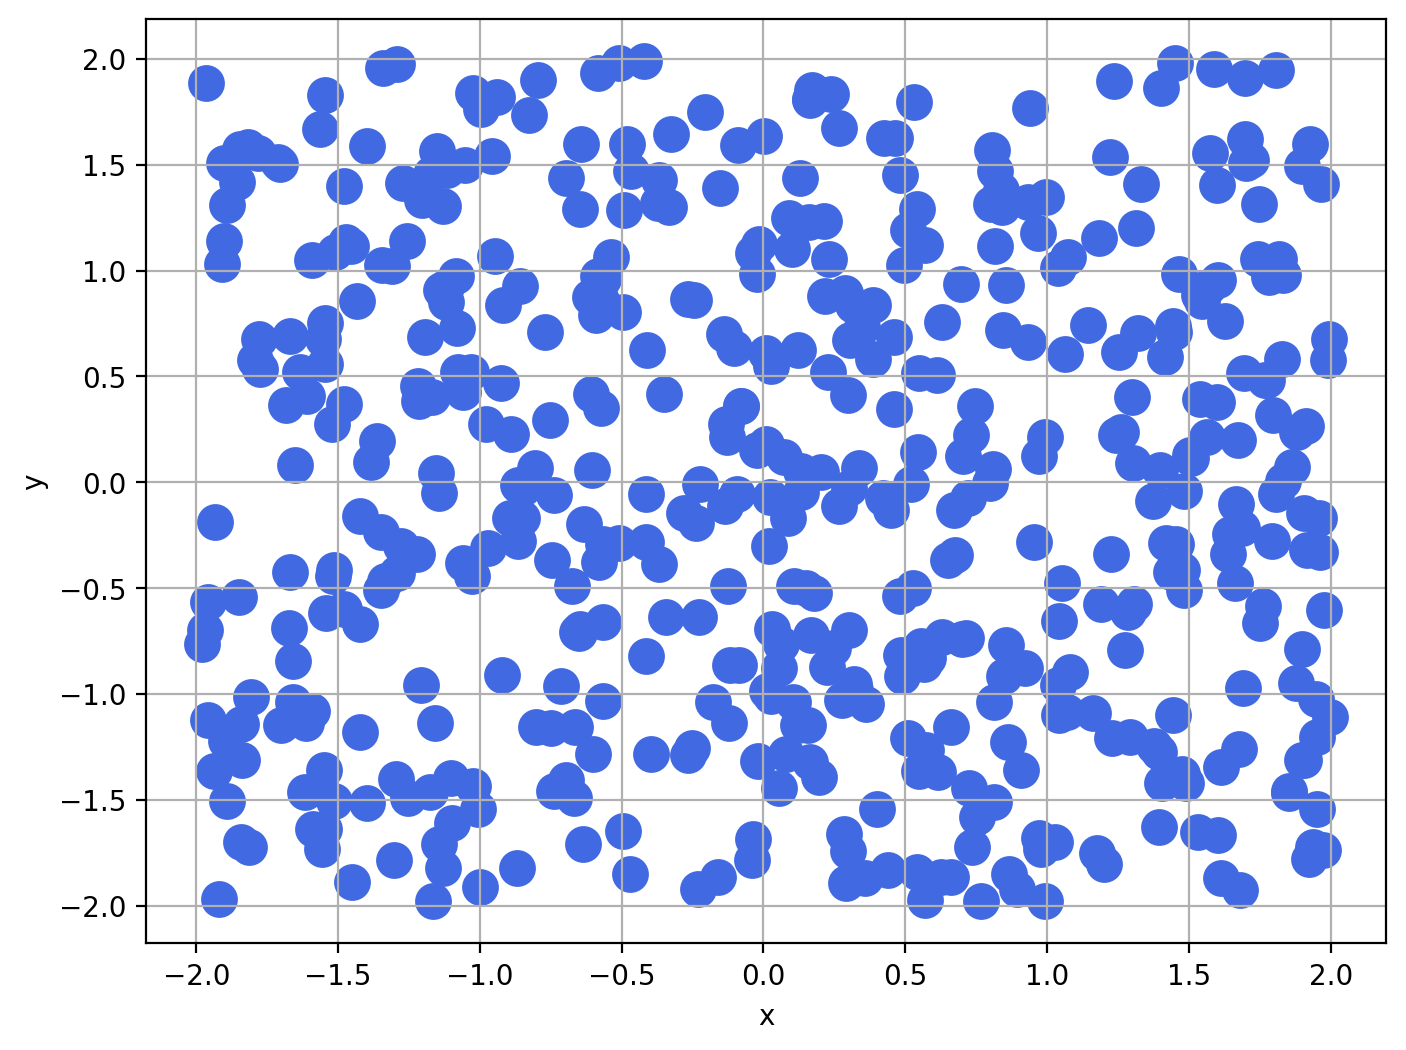

NameError: name 'energy' is not defined

In [ ]:
pearson_corr, distance_corr = show_xy(x, y)
print('=== Five Hundred Random Points === ')
print('Pearson Correlation = {:,.8f}'.format(pearson_corr[0]))
print('  Test Significance = {:,.8f}'.format(pearson_corr[1]))
print('Distance Correlation = {:,.8f}'.format(distance_corr[0]))